[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/aprendizaje-automatico-dc-uba-ar/material/blob/main/notebooks/lferrer/3_psrs-published.ipynb)

# Comparison of EPSRs and calibration metrics

This notebook compares the two EPSRs most used in the literature, Brier score and cross-entropy, and calibration metrics, Calibration Loss and ECE.
For calibration loss we compare various ways of obtaining the minimum EPSR.

In [2]:
# ! git clone https://github.com/luferrer/expected_cost.git
# ! git clone https://github.com/luferrer/psr-calibration.git

In [3]:
# absolute paths
PATH_TO_EXPECTED_COST = "..."
PATH_TO_PSR_CALIBRATION = "..."

In [12]:
import sys
sys.path += [PATH_TO_EXPECTED_COST, PATH_TO_PSR_CALIBRATION]

In [13]:
import matplotlib.pyplot as plt
import numpy as np
#import torch
from expected_cost import ec, utils
from expected_cost.data import create_scores_for_expts
from expected_cost.psrcal_wrappers import LogLoss, ECE, ECEbin, Brier, CalLoss
from psrcal.losses import plot_reliability_diagram

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'none'

ModuleNotFoundError: No module named 'torch'

In [3]:
# Create the scores using a general method from the repo and select a subset of them.

num_targets = 2  # Number of classes
N = 400          # Total number of samples
std = 0.15       # Within-class variance of the features. Determines the difficulty of the problem.and

score_dict, targets = create_scores_for_expts(num_targets, N=N, P0=0.8, feat_std=std, calibrate=True, simple_names=True)

# score_dict has four different scores:
# cal: perfectly calibrated scores
# mcp: scores miscalibrated due to a mismatch in priors between the training and the test data
# mcs: scores miscalibrated due to (simulated) overfitting of the model
# mcps: scores miscalibrated due to both causes above

# For each of those we have the raw version (uncalibrated) and three calibrated versions:
# Affcal: affine transform of the log-posteriors
# Temcal: only scaling of the log-posteriors (same as above but without the shift)
# Hiscal: histogram binning, as done for ECE

# And two ways of training each of those models
# tt: train-on-test (cheating, as done for ECE)
# xv: cross-validation on the test data (non-cheating)

print(score_dict.keys())

# Create the three cost matrices used in the paper: 0-1 cost, 0-1 cost with abstention, and an
# imbalanced cost matrix

cost_01  = ec.CostMatrix.zero_one_costs(num_targets)
cost_ab1 = ec.CostMatrix.zero_one_costs(num_targets, abstention_cost=0.1)

m = cost_01.get_matrix().copy()
m[num_targets-1,:] = 10
m[num_targets-1,num_targets-1] = 0
cost_im = ec.CostMatrix(m)

color = ['blue', 'red', 'green', 'yellow']
score_names = ['cal', 'mcp', 'mcs', 'mcps']


dict_keys(['cal', 'mcp', 'mcs', 'mcps', 'cal-affcalxv', 'mcp-affcalxv', 'mcs-affcalxv', 'mcps-affcalxv', 'cal-affcaltt', 'mcp-affcaltt', 'mcs-affcaltt', 'mcps-affcaltt', 'cal-temcalxv', 'mcp-temcalxv', 'mcs-temcalxv', 'mcps-temcalxv', 'cal-temcaltt', 'mcp-temcaltt', 'mcs-temcaltt', 'mcps-temcaltt', 'cal-hiscalxv', 'mcp-hiscalxv', 'mcs-hiscalxv', 'mcps-hiscalxv', 'cal-hiscaltt', 'mcp-hiscaltt', 'mcs-hiscaltt', 'mcps-hiscaltt'])


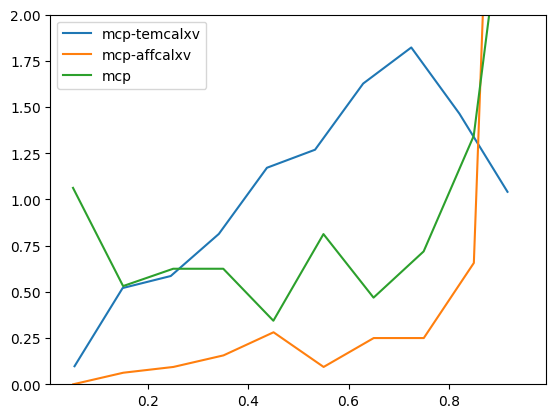

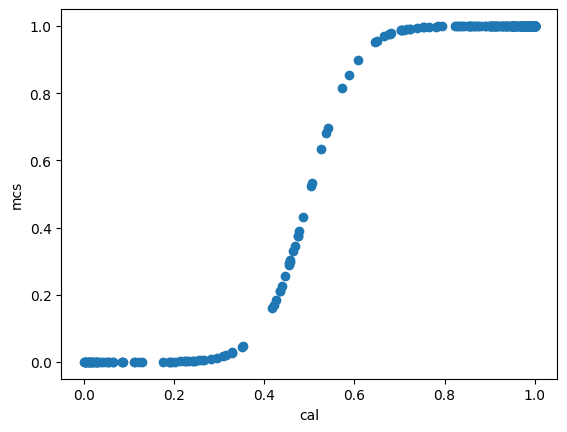

In [4]:
# Plot one of the scores (you can change the score name to any of the other three)
# raw and after calibration.

if num_targets == 2:
    score_name = 'mcp'
    for suffix in ['-temcalxv', '-affcalxv','']:
        scores = score_dict[score_name+suffix]
        c, h = utils.make_hist(targets, np.exp(scores),nbins=10)
        plt.plot(c,h[0],label=score_name+suffix)
    plt.ylim(0,2)
    plt.legend()

    # Plot the calibrated vs mcs scores to see the effect of the scaling. Basically, most of the scores
    # have values close to 0 or 1, which is what happens in overfitting DNNs trained with cross-entropy

    plt.figure()
    plt.scatter(np.exp(score_dict['cal'][:,0]), np.exp(score_dict['mcs'][:,0]))
    plt.xlabel('cal')
    plt.ylabel('mcs')

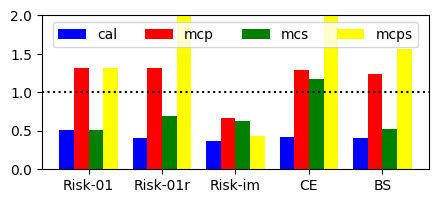

In [5]:
# Compute and plot all the overall metrics

metric_dict = {
    'Risk-01': cost_01,
    'Risk-01r': cost_ab1,
    'Risk-im': cost_im,
    'CE': LogLoss,
    'BS': Brier
    }

# Use normalized metrics

adjusted_cost = True

# Figure stuff

fig, ax = plt.subplots(figsize=(5,2))
barWidth = 0.2

for j, score_name in enumerate(score_names):

    scores = score_dict[score_name]

    xvalues = np.arange(len(metric_dict)) + barWidth * j
    yvalues = []

    for metric_name, metric in metric_dict.items():

        if 'Risk' in metric_name:
            val = ec.average_cost_for_bayes_decisions(targets, scores, metric, adjusted=adjusted_cost, silent=True)[0]
        else:
            val = metric(scores, targets, norm=adjusted_cost)

        yvalues.append(val)

    ax.bar(xvalues, yvalues, color =color[j], width = barWidth, label = score_name)

ax.legend(loc='upper center', ncol=4)
ax.set_xticks(np.arange(len(metric_dict)) + barWidth * 1.5, metric_dict.keys())

xvalues = ax.get_xlim()
ax.plot(xvalues, np.ones_like(xvalues), ':k')
ax.set_xlim(xvalues)
ax.set_ylim([0, min(2,ax.get_ylim()[1])])


The three risks give different conclusions on which is the worst system. Cross-entropy (CE) and Brier (BS) give a different weighted average of various risks. BS penalizes less the mcs system. This is because it does not care that much about extreme mistakes caused by the scaling in those scores.


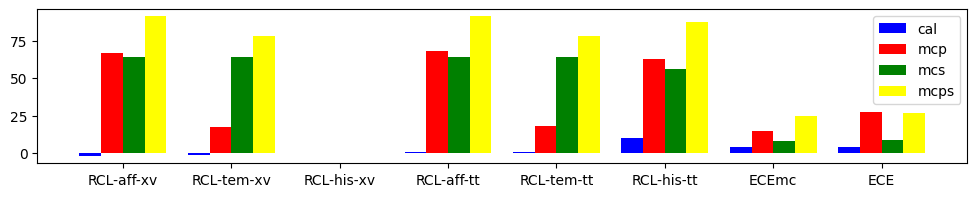

In [6]:
# Compute and plot the calibration metrics
# Calibration losses based on LogLoss and Brier, and the original binary ECE and the hacky multi-class version.

metric_dict = {'RCL': LogLoss, # Can be Brier or LogLoss
               'ECEmc': ECE}

if num_targets == 2:
    metric_dict['ECE'] = ECEbin

calmethods = ['aff', 'tem', 'his']
traintypes = ['xv', 'tt']

if num_targets == 2:
    fig, ax = plt.subplots(figsize=(12,2))
else:
    fig, ax = plt.subplots(figsize=(10,2))

for j, score_name in enumerate(score_names):

    scores = score_dict[score_name]

    yvalues = []
    full_metric_names = []

    for metric_name, metric in metric_dict.items():

        if "ECE" in metric_name:
            val = metric(scores, targets)
            full_metric_names.append(metric_name)
            yvalues.append(val)
        else:
            # For CalLoss metrics, we have various choices on how to create the calibrated scores
            # (affcal, temcal, hiscal, each trained with xval or train on test.

            for traintype in traintypes:
                for calmethod in calmethods:
                    score_name_cal = score_name + "-" + calmethod + "cal" + traintype

                    if metric_name == "CL-CE" and 'his' in calmethod: continue
                    if score_name_cal not in score_dict: continue

                    scores_cal = score_dict[score_name_cal]
                    val = CalLoss(metric, scores, scores_cal, targets)
                    full_metric_names.append(metric_name + "-" + calmethod + '-' + traintype)
                    yvalues.append(val)

    xvalues = np.arange(len(full_metric_names)) + barWidth * j
    ax.bar(xvalues, yvalues, color =color[j], width = barWidth, label = score_name)

ax.set_xticks(np.arange(len(full_metric_names)) + barWidth*1.5, full_metric_names)
ax.legend()


Observations from plot above (when run with LogLoss as metric):

* **RCL-his-xv**: The CE cannot be computed for histogram binning because some bins map the posteriors to 0 and that gives a CE of infinity.
* **RCL-tem-xv and RCL-tem-tt**: Both RCLs obtained with temp scaling fail to diagnose the miscalibration in mcp because that method cannot correct issues with the priors
* **RCL-his-tt**: Hallucinates a calibration problem in the cal scores because the calibration transform overfits the test data.
* **ECEs**: Also hallucinate an unexisting problem on the cal scores. Their absolute value is hard to interpret, while for RCL, the value is the percentage of the original EPSR that can be reduced by doing calibration.

Overall, we see that histogram binning is a pretty poor calibration method and that training calibration on test data is dangerous. As a consequence, the ECE is a very poor calibration metric.


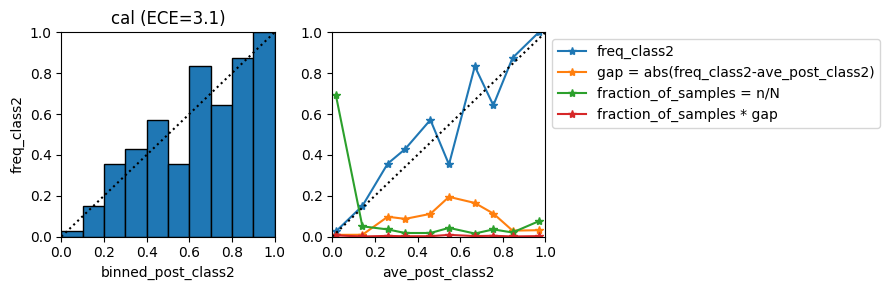

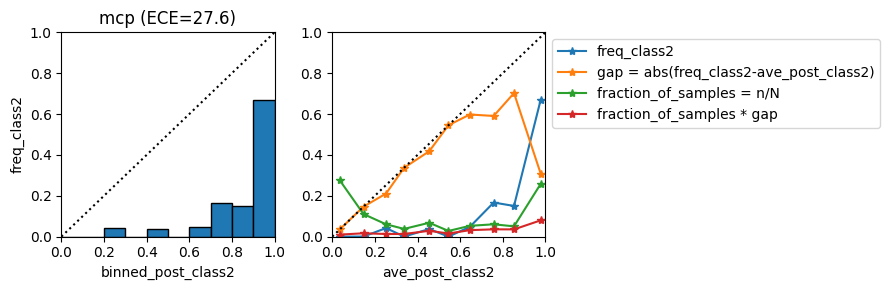

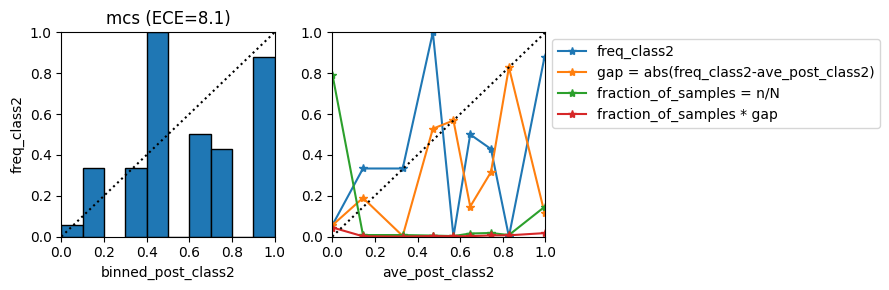

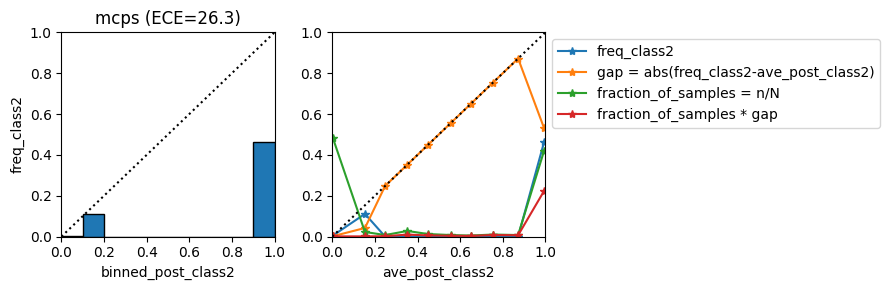

In [8]:
# Plot our version of the reliability diagram, using curves instead of bars and plotting some of the
# quantities involved in the ECE computation. The ECE is equal to the sum over all markers in the
# red curve, multiplied by 100. The usual reliability diagram is included on the right for
# comparison. The main difference is that the bars do not show the average posterior within the bar,
# which is what is actually used to compute the ECE. Further, the bars do not show the fraction of
# samples in each bin which is also used to compute the ECE.

for j, score_name in enumerate(score_names):

    scores = score_dict[score_name]

    if num_targets == 2:
        metric_value, ys, xs, counts, limits = ECEbin(scores, targets, return_values=True, M=10)
        plot_reliability_diagram(ys, xs, counts, limits, title=score_name)
    else:
        metric_value, ys, xs, counts, limits = ECE(scores, targets, return_values=True, M=10)
        plot_reliability_diagram(ys, xs, counts, limits, title=score_name)

